In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")    

df=pd.read_csv('../data/uec_data_2023_2025_full.csv')

In [2]:
df['weekday']= pd.to_datetime(df['Date'], dayfirst=True).dt.day_of_week

In [3]:
hosp_sums=df.groupby('Hospital')['Total'].sum()
hospitals_over_1 = hosp_sums[hosp_sums > 1].index.tolist()

## Plot Encatchment Areas

In [4]:
pop_df=pd.read_csv("../data/encatchment_areas.csv")

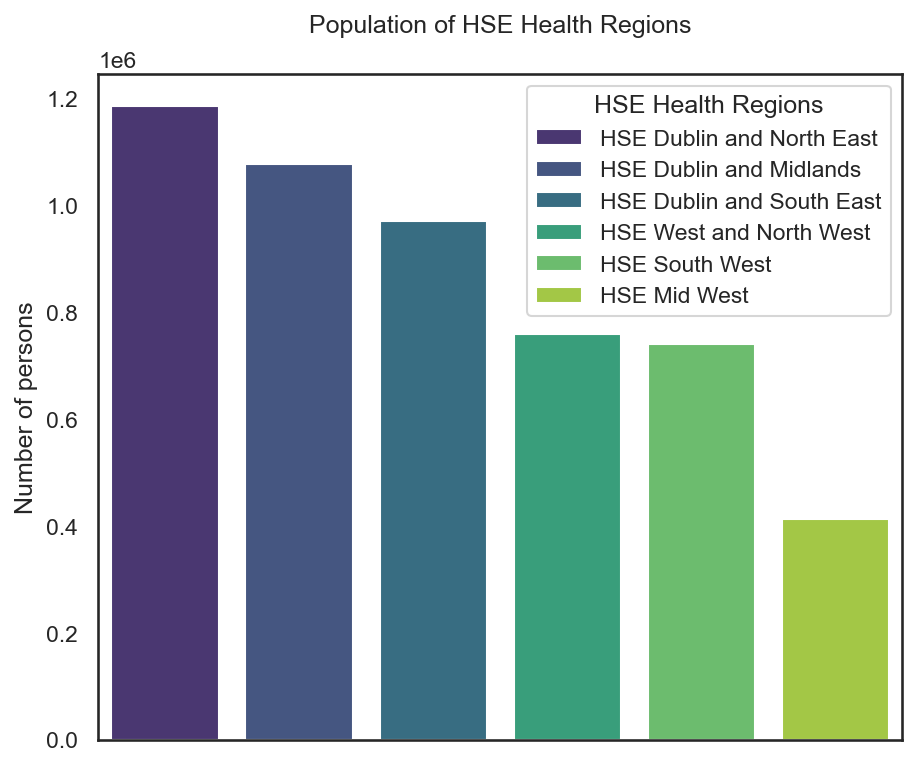

In [5]:
pop_df_sorted = pop_df.sort_values('Number of persons', ascending=False).reset_index(drop=True)
region_order = pop_df_sorted['HSE Health Regions'].tolist()

plt.figure(figsize=(6, 5), dpi=150, layout='constrained')
ax = plt.gca()
ax.set_title("Population of HSE Health Regions", pad=20)
sns.barplot(data=pop_df_sorted, x='HSE Health Regions', y='Number of persons',
            hue='HSE Health Regions', hue_order=region_order, order=region_order,
            palette='viridis', legend=True)
ax.set_xlabel('')
ax.set_xticks([])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='HSE Health Regions')